# Analyse Exploratoire des Données - Churn Bancaire

Ce notebook a pour objectif d'explorer le jeu de données `data_churn.csv` qui contient des informations sur les comptes bancaires, leurs caractéristiques et leur statut (actif / fermé). L'objectif final est de comprendre les facteurs associés au churn (fermeture de compte).

---

## 1. Importation des bibliothèques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# supprime la notation scientifique
pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(suppress=True)  


%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 2. Chargement des données

In [3]:
# Chargement du fichier CSV
df = pd.read_csv(r"C:\Users\HP\Downloads\data_churn.txt", sep=",")

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
df.head()

Nombre de lignes : 528883
Nombre de colonnes : 34


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,...,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
0,C318650,A0365322,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251227.00,1290627.00,10954600.00,4.50,CURRENT,Retail,4
1,C318648,A0373555,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,...,DEPOSITS,BANK.CAT.NEG.SIM,DEPOTS A TERME,20260102.00,NaN,NaN,NaN,UNAUTH,Retail,4
2,C318650,A0348290,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.548,Crédit rénovation,1251227.00,1380527.00,113593077.00,4.50,CURRENT,Retail,4
3,C318650,A0257995,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,ACCOUNTS,BANK.CUR.ACCT.ALL.TOURS.CARTE,Compte Allocation Touristique TND,NaN,NaN,0.00,NaN,NaN,Retail,4
4,C318648,A0312991,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,...,NaN,NaN,DEPOTS A TERME,NaN,NaN,NaN,NaN,NaN,Retail,4


In [4]:
df["CURRENCY"]

0         TND
1         TND
2         TND
3         TND
4         TND
         ... 
528878    TND
528879    TND
528880    TND
528881    TND
528882    NaN
Name: CURRENCY, Length: 528883, dtype: str

## 3. Aperçu des données et types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 528883 entries, 0 to 528882
Data columns (total 34 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CUSTOMER_NO        528883 non-null  str    
 1   ACCOUNT_NO         484443 non-null  str    
 2   NATIONALITY        528883 non-null  str    
 3   RESIDENCE          528883 non-null  str    
 4   MARITAL_STATUS     410185 non-null  str    
 5   CUST_OPENING_DATE  515261 non-null  float64
 6   DATE_OF_BIRTH      427568 non-null  float64
 7   NATURE_CLIENT      528805 non-null  str    
 8   BRANCH             528883 non-null  str    
 9   SCORE_KYC          528038 non-null  str    
 10  COMPLETED_FILE     289239 non-null  str    
 11  LAST_REVIEW_DATE   501478 non-null  float64
 12  NEXT__REVIEW_DATE  504301 non-null  float64
 13  ACCOUNT_STATUS     484443 non-null  str    
 14  ACCT_OPENING_DATE  383958 non-null  float64
 15  ACCOUNT_CATEGORY   383958 non-null  float64
 16  ACCOUNT_TYPE_

In [6]:
# Statistiques descriptives pour les colonnes numériques
df.describe()

,CUST_OPENING_DATE,DATE_OF_BIRTH,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCT_OPENING_DATE,ACCOUNT_CATEGORY,ACCT_CLOSE_DATE,ACCT_BALANCE,INDUSTRY,SALARY,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,LOB
count,515261.00,427568.00,501478.00,504301.00,383958.00,383958.00,221941.00,383958.00,528883.00,202234.00,92727.00,79550.00,305363.00,79548.00,528883.00
mean,20136149.53,1976.25,20221483.27,20255637.90,20191930.61,4999.71,20241817.93,4409.02,7983.97,5588.48,6270502.37,3980789.49,41297692.49,8.65,6.06
std,68027.23,17.29,35431.95,34841.38,78138.15,2170.51,13875.96,810619.54,2511.47,149836.63,8375981.70,6629581.69,442802606.00,2.49,5.46
min,19960122.00,1190.00,20040930.00,20060930.00,19800101.00,1001.00,20220412.00,-43823115.66,111.00,0.00,1131130.00,-19000000.00,-43823115.66,0.00,1.00
25%,20070824.00,1964.00,20200923.00,20240610.00,20151209.00,3045.00,20230410.00,0.00,9000.00,400.00,1251225.00,1260318.00,7.08,8.33,4.00
50%,20140925.00,1977.00,20230323.00,20261017.00,20220720.00,6001.00,20241108.00,2.09,9000.00,612.00,1251231.00,1261205.00,1510.60,9.33,4.00
75%,20191108.00,1989.00,20250508.00,20280217.00,20251029.00,6001.00,20251205.00,1087.91,9000.00,1647.00,20250530.00,1341031.00,149000.00,10.08,4.00
max,20260219.00,2026.00,20260219.00,20301230.00,20260219.00,9005.00,20260219.00,64141930.15,9998.00,25000000.00,20261226.00,20310123.00,31714285714.00,13.33,999.00


In [7]:
# Statistiques pour les colonnes catégorielles
df.describe(include=['object']).T

,count,unique,top,freq
CUSTOMER_NO,528883,363569,C155581,8091
ACCOUNT_NO,484443,410587,A0164634,93
NATIONALITY,528883,141,TN,509824
RESIDENCE,528883,137,TN,494836
MARITAL_STATUS,410185,4,M,219232
NATURE_CLIENT,528805,9,PPH,374968
BRANCH,528883,142,BR114,26573
SCORE_KYC,528038,5,LR,342717
COMPLETED_FILE,289239,1,YES,289239
ACCOUNT_STATUS,484443,2,Active,262502


## 4. Analyse des valeurs manquantes

### 4.1. Nombre de valeurs manquantes par colonne

Top 20 colonnes avec valeurs manquantes :


,Missing,Pct
MATURITYDATE,449333,84.96
FIXEDRATE,449335,84.96
PRODUCT_STATUS,436160,82.47
STARTDATE,436156,82.47
CLOSURE_REASON,385328,72.86
SALARY,326649,61.76
ACCT_CLOSE_DATE,306942,58.04
COMPLETED_FILE,239644,45.31
AMOUNT,223520,42.26
PRODUCT_LINE,208846,39.49


En jaune les valeurs manquantes, en violet les valeurs présentes.


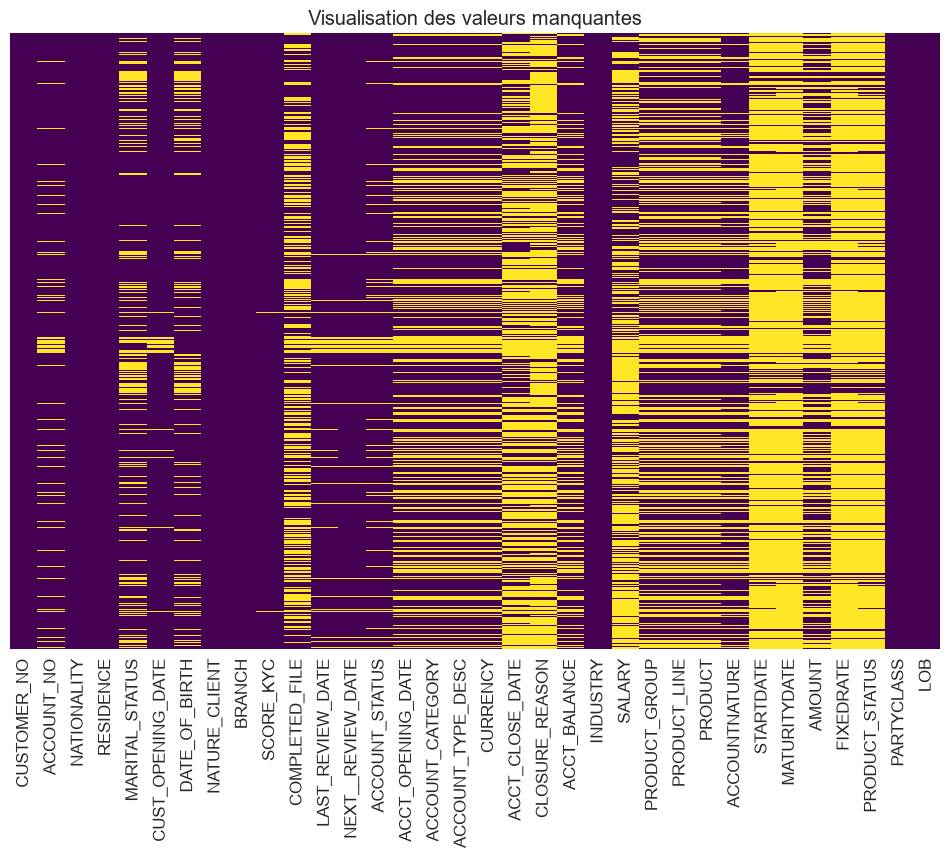

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Pct', ascending=False)

print("Top 20 colonnes avec valeurs manquantes :")
display(missing_df)

# Heatmap (échantillon)
print("En jaune les valeurs manquantes, en violet les valeurs présentes.")
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Visualisation des valeurs manquantes')
plt.show()



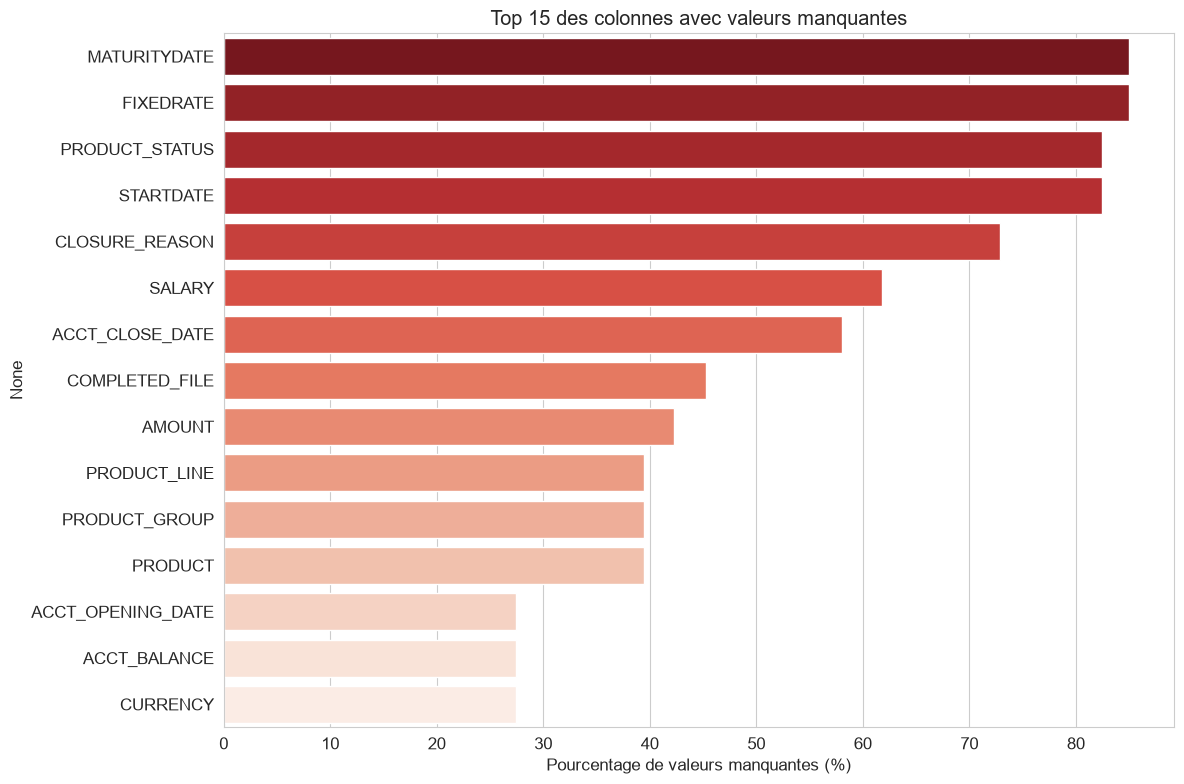

In [9]:
# Visualisation des 15 colonnes avec le plus de missing
plt.figure(figsize=(12, 8))
top_missing = missing_df.head(15)
sns.barplot(x=top_missing['Pct'], y=top_missing.index, palette='Reds_r')
plt.xlabel('Pourcentage de valeurs manquantes (%)')
plt.title('Top 15 des colonnes avec valeurs manquantes')
plt.tight_layout()
plt.show()

### 4.2. Distribution du nombre de valeurs manquantes par ligne (histogramme)

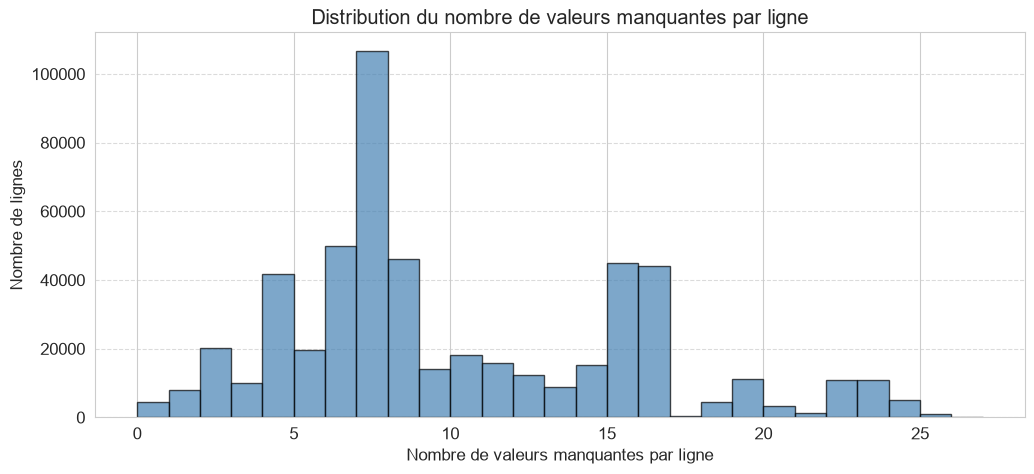

Lignes avec au moins une valeur manquante : 524360
Lignes sans aucune valeur manquante : 4523


In [10]:
row_missing_count = df.isnull().sum(axis=1)
plt.figure(figsize=(12, 5))
plt.hist(row_missing_count, bins=range(0, row_missing_count.max()+2), edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Nombre de valeurs manquantes par ligne')
plt.ylabel('Nombre de lignes')
plt.title('Distribution du nombre de valeurs manquantes par ligne')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Lignes avec au moins une valeur manquante : {(row_missing_count > 0).sum()}")
print(f"Lignes sans aucune valeur manquante : {(row_missing_count == 0).sum()}")

In [11]:
# --- Analyse des doublons ---

# 1. Nombre total de lignes dupliquées (toutes colonnes identiques)
duplicates_all = df.duplicated()
print(f"Nombre de lignes parfaitement dupliquées (toutes colonnes) : {duplicates_all.sum()}")
print(f"Pourcentage de doublons stricts : {duplicates_all.sum() / len(df) * 100:.2f}%")

# 2. Afficher un échantillon des lignes dupliquées
if duplicates_all.sum() > 0:
    print("\nAperçu des premières lignes dupliquées (toutes colonnes) :")
    display(df[duplicates_all].head())
else:
    print("\nAucun doublon parfait trouvé.")

# 3. Doublons basés sur des colonnes clés (identifiants client et compte)
key_cols = ['CUSTOMER_NO', 'ACCOUNT_NO']
duplicates_key = df.duplicated(subset=key_cols, keep=False)  # keep=False pour marquer toutes les occurrences

print(f"\nNombre de lignes ayant un couple (CUSTOMER_NO, ACCOUNT_NO) en double : {duplicates_key.sum()}")
print(f"Nombre de groupes de doublons sur ces clés : {duplicates_key.sum() // 2} (estimation)")

# 4. Afficher les groupes de doublons sur les clés
if duplicates_key.sum() > 0:
    print("\nExemples de groupes de doublons sur (CUSTOMER_NO, ACCOUNT_NO) :")
    dup_groups = df[duplicates_key].sort_values(key_cols)
    # Afficher les 10 premières lignes des groupes
    display(dup_groups.head(10))
    
    # Optionnel : montrer un groupe spécifique
    first_dup_cust = df[duplicates_key].iloc[0]['CUSTOMER_NO']
    first_dup_acct = df[duplicates_key].iloc[0]['ACCOUNT_NO']
    print(f"\nDétail du premier groupe doublon (client {first_dup_cust}, compte {first_dup_acct}) :")
    display(df[(df['CUSTOMER_NO'] == first_dup_cust) & (df['ACCOUNT_NO'] == first_dup_acct)])
else:
    print("\nAucun doublon détecté sur les colonnes clés.")

Nombre de lignes parfaitement dupliquées (toutes colonnes) : 38640
Pourcentage de doublons stricts : 7.31%

Aperçu des premières lignes dupliquées (toutes colonnes) :


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,...,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
329,C318601,A0312191,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,...,ACCOUNTS,BANK.INDISPO.ACCT.CLT.DECE.RESI,CPT INDISP CLIENT DECEDE RESIDENT,NaN,NaN,0.00,NaN,NaN,Retail,4
662,C318088,A0018016,TN,TN,M,20040930.00,1977.00,PPH,BR114,LR,...,ACCOUNTS,BANK.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,0.12,NaN,NaN,Retail,4
670,C318607,A0318537,TN,TN,M,20040930.00,1962.00,PRO,BR114,H1,...,LENDING,AVC.CPTATERME.TND,AVANCE SUR COMPTE A TERME EN DIANRS,NaN,NaN,NaN,NaN,NaN,Retail,4
671,C318607,A0267148,TN,TN,M,20040930.00,1962.00,PRO,BR114,H1,...,ACCOUNTS,BANK.CURRENT.ACCT,Compte Courant,NaN,NaN,4.91,NaN,NaN,Retail,4
672,C318607,A0314507,TN,TN,M,20040930.00,1962.00,PRO,BR114,H1,...,DEPOSITS,BANK.CAT.NEG.SIM,DEPOTS A TERME,20250728.00,NaN,NaN,NaN,PENDING.CLOSURE,Retail,4



Nombre de lignes ayant un couple (CUSTOMER_NO, ACCOUNT_NO) en double : 89051
Nombre de groupes de doublons sur ces clés : 44525 (estimation)

Exemples de groupes de doublons sur (CUSTOMER_NO, ACCOUNT_NO) :


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,...,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
512776,C000696,A0393356,TN,TN,C,20201028.00,1993.00,PPH,BR114,LR,...,NaN,NaN,Retrait par Carte LELLA,NaN,NaN,NaN,NaN,NaN,Retail,4
512804,C000696,A0393356,TN,TN,C,20201028.00,1993.00,PPH,BR114,LR,...,NaN,NaN,Retrait par Carte LELLA,NaN,NaN,NaN,NaN,NaN,Retail,4
512777,C000696,A0404413,TN,TN,C,20201028.00,1993.00,PPH,BR114,LR,...,NaN,NaN,Crédit a la consommation TEGF3,NaN,NaN,NaN,NaN,NaN,Retail,4
512805,C000696,A0404413,TN,TN,C,20201028.00,1993.00,PPH,BR114,LR,...,NaN,NaN,Crédit a la consommation TEGF3,NaN,NaN,NaN,NaN,NaN,Retail,4
512778,C000696,A0409917,TN,TN,C,20201028.00,1993.00,PPH,BR114,LR,...,NaN,NaN,Crédit a la consommation TEGF3,NaN,NaN,NaN,NaN,NaN,Retail,4
512806,C000696,A0409917,TN,TN,C,20201028.00,1993.00,PPH,BR114,LR,...,NaN,NaN,Crédit a la consommation TEGF3,NaN,NaN,NaN,NaN,NaN,Retail,4
513063,C000913,A0300530,TN,TN,C,20211110.00,1996.00,PPH,BR92,LR,...,ACCOUNTS,BANK.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,0.76,NaN,NaN,Retail,4
513084,C000913,A0300530,TN,TN,C,20211110.00,1996.00,PPH,BR92,LR,...,ACCOUNTS,BANK.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,0.76,NaN,NaN,Retail,4
513062,C000913,A0316398,TN,TN,C,20211110.00,1996.00,PPH,BR92,LR,...,ACCOUNTS,BANK.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,22.09,NaN,NaN,Retail,4
513083,C000913,A0316398,TN,TN,C,20211110.00,1996.00,PPH,BR92,LR,...,ACCOUNTS,BANK.EPARG.ACCT.SPECIAUX,Comptes Spéciaux d épargne,NaN,NaN,22.09,NaN,NaN,Retail,4



Détail du premier groupe doublon (client C318650, compte A0365322) :


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,...,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
0,C318650,A0365322,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251227.00,1290627.00,10954600.00,4.50,CURRENT,Retail,4
65,C318650,A0365322,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251227.00,1290627.00,10954600.00,4.50,CURRENT,Retail,4


## 5. Analyse de la variable cible : `ACCOUNT_STATUS`

Nous considérons qu’un compte **fermé** correspond à un **churn**. L’objectif est de comprendre quels facteurs influencent le passage à l’état `Closed`.

Répartition de ACCOUNT_STATUS :
                 Count  Percentage
ACCOUNT_STATUS                    
Active          262502       54.19
Closed          221941       45.81


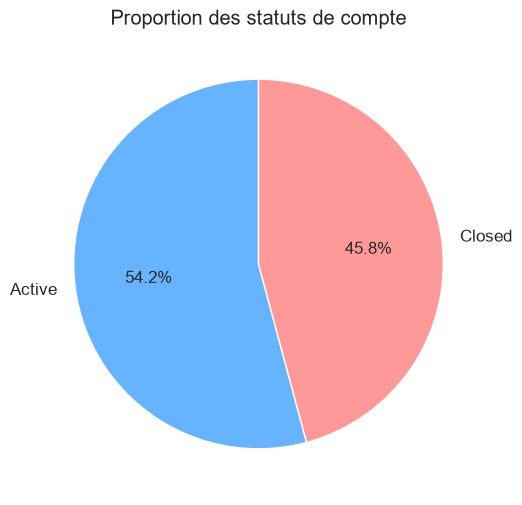

In [12]:
status_counts = df['ACCOUNT_STATUS'].value_counts()
status_pct = df['ACCOUNT_STATUS'].value_counts(normalize=True) * 100

print("Répartition de ACCOUNT_STATUS :")
print(pd.DataFrame({'Count': status_counts, 'Percentage': status_pct}))

plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Proportion des statuts de compte')
plt.show()

## 6. Analyse univariée des variables numériques

### 6.1. Distribution des âges (via `DATE_OF_BIRTH`)

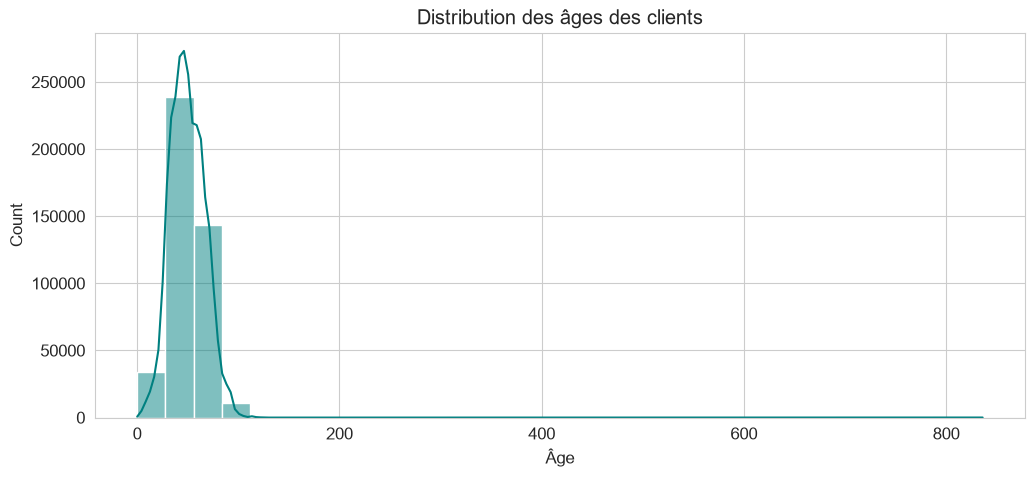

Âge moyen : 49.7 ans
Âge médian : 49.0 ans


DATE_OF_BIRTH
1190.00    3
1191.00    2
1193.00    1
1195.00    1
1197.00    1
1198.00    1
1373.00    1
1645.00    1
1657.00    1
1659.00    1
1672.00    1
1692.00    1
1696.00    1
1697.00    3
1798.00    1
1850.00    1
1851.00    1
1874.00    2
1882.00    1
1888.00    1
1890.00    1
Name: count, dtype: int64

In [13]:
# Calcul de l'âge (approximatif) à partir de DATE_OF_BIRTH (format AAAAMMJJ)
def age_from_date_of_birth(dob):
    try:
        year = int(str(dob)[:4])
        return 2026 - year  # année de référence pour l'analyse
    except:
        return np.nan

df['AGE'] = df['DATE_OF_BIRTH'].apply(age_from_date_of_birth)

plt.figure(figsize=(12, 5))
sns.histplot(df['AGE'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribution des âges des clients')
plt.xlabel('Âge')
plt.show()

print(f"Âge moyen : {df['AGE'].mean():.1f} ans")
print(f"Âge médian : {df['AGE'].median():.1f} ans")

# Analyse des anomalies dans les dates de naissance pour les clients nés avant 1900
df[df['DATE_OF_BIRTH'] < 1900]['DATE_OF_BIRTH'].value_counts().sort_index()

### 6.2. Distribution du `SCORE_KYC`

### Interprétation du `SCORE_KYC`

Le `SCORE_KYC` classe les clients par niveau de risque de conformité. Les codes sont interprétés comme suit :

- **LR** (Low Risk) : risque faible - clients standards, sources de revenus claires.
- **MR** (Medium Risk) : risque moyen - nécessitant une vigilance accrue mais sans alerte majeure.
- **H1, H2, H3** (High Risk) : risque élevé - clients pouvant être politiquement exposés (PEP), opérant dans des zones sensibles, ou présentant des anomalies documentaires. `H1` est le niveau le moins critique parmi les H, `H3` le plus sévère.

Dans l’EDA, nous pouvons observer que les comptes avec un score `H` (haut risque) ferment souvent plus tard ou présentent des soldes négatifs, ce qui peut indiquer une gestion particulière de ces dossiers.

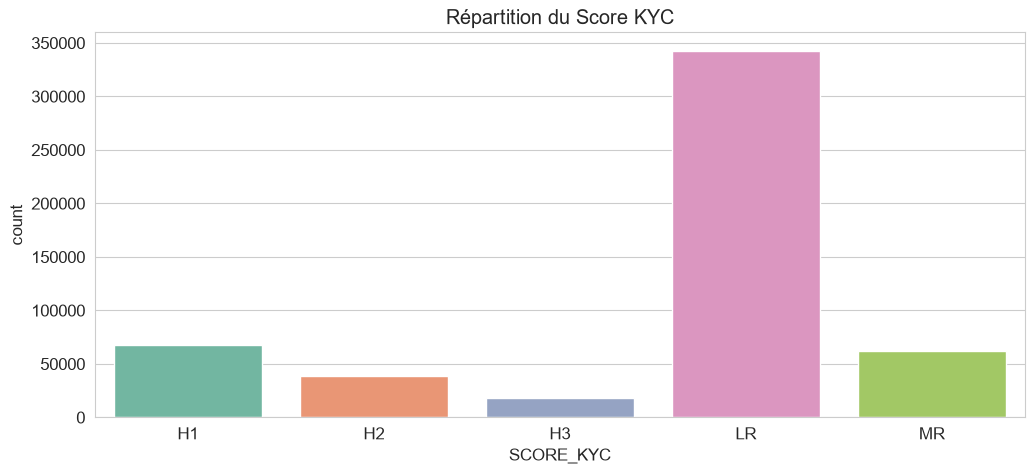

In [14]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='SCORE_KYC', order=sorted(df['SCORE_KYC'].dropna().unique()), palette='Set2')
plt.title('Répartition du Score KYC')
plt.show()

=== Matrice de contingence (effectifs) ===
ACCOUNT_STATUS  Active  Closed   Total
SCORE_KYC                             
H1               24212   41512   65724
H2                9227   17014   26241
H3                4494   12619   17113
LR              188330  127045  315375
MR               36188   23743   59931
Total           262451  221933  484384

=== Répartition en % par SCORE_KYC (ligne) ===
ACCOUNT_STATUS  Active  Closed
SCORE_KYC                     
H1               36.84   63.16
H2               35.16   64.84
H3               26.26   73.74
LR               59.72   40.28
MR               60.38   39.62


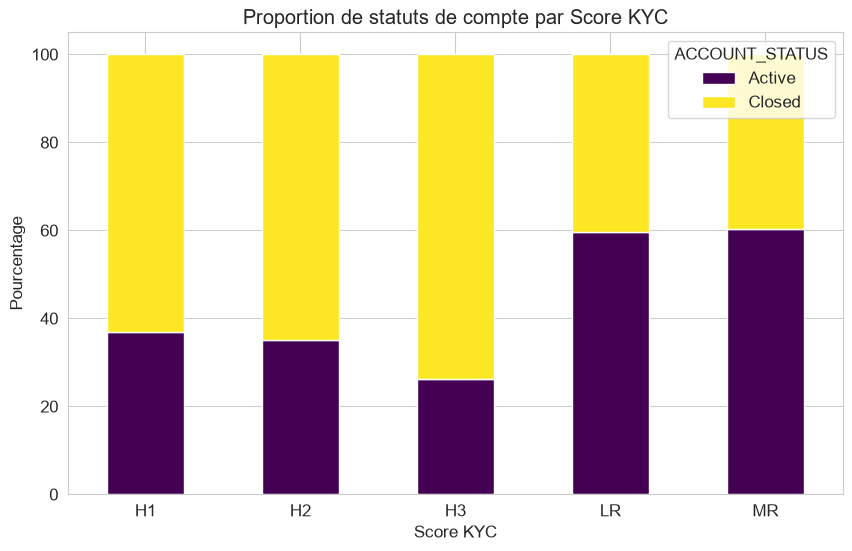

In [15]:
# Matrice croisée entre SCORE_KYC et ACCOUNT_STATUS
cross_tab = pd.crosstab(df['SCORE_KYC'], df['ACCOUNT_STATUS'], margins=True, margins_name='Total')
print("=== Matrice de contingence (effectifs) ===")
print(cross_tab)

# En pourcentages par ligne (profil selon SCORE_KYC)
cross_tab_pct = pd.crosstab(df['SCORE_KYC'], df['ACCOUNT_STATUS'], normalize='index') * 100
print("\n=== Répartition en % par SCORE_KYC (ligne) ===")
print(cross_tab_pct)

# Visualisation avec barres empilées
cross_tab_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Proportion de statuts de compte par Score KYC')
plt.ylabel('Pourcentage')
plt.xlabel('Score KYC')
plt.legend(title='ACCOUNT_STATUS')
plt.xticks(rotation=0)
plt.show()

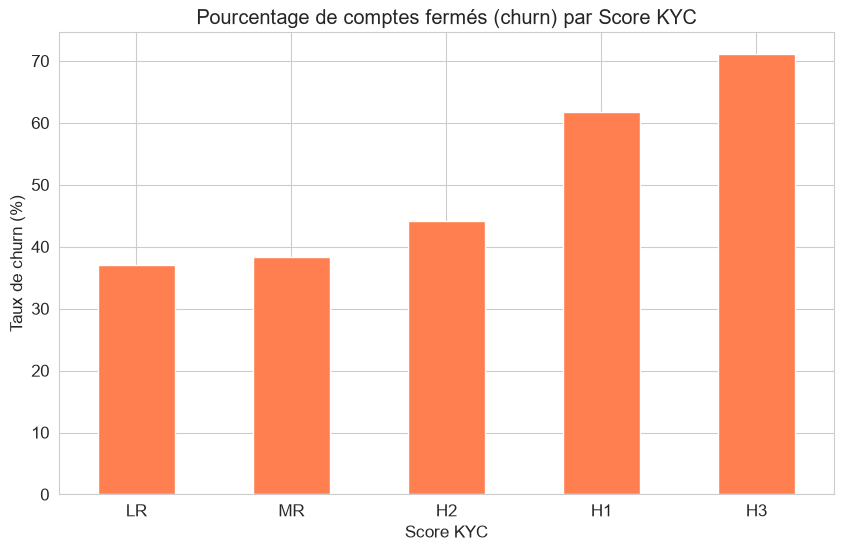

In [16]:
churn_by_kyc = df.groupby('SCORE_KYC')['ACCOUNT_STATUS'].apply(lambda x: (x == 'Closed').mean() * 100)
plt.figure(figsize=(10, 6))
churn_by_kyc.sort_values().plot(kind='bar', color='coral')
plt.title('Pourcentage de comptes fermés (churn) par Score KYC')
plt.ylabel('Taux de churn (%)')
plt.xlabel('Score KYC')
plt.xticks(rotation=0)
plt.show()

### 6.3. Distribution du `SALARY` (salaire déclaré)

=== Statistiques descriptives de SALARY ===
count     202234.00
mean        5588.48
std       149836.63
min            0.00
1%           400.00
5%           400.00
25%          400.00
50%          612.00
75%         1647.00
95%         5000.00
99%        20000.00
max     25000000.00
Name: SALARY, dtype: float64

=== Quantiles détaillés ===
Quantile 1% : 400.00
Quantile 5% : 400.00
Quantile 10% : 400.00
Quantile 25% : 400.00
Quantile 50% : 612.00
Quantile 75% : 1647.00
Quantile 90% : 4000.00
Quantile 95% : 5000.00
Quantile 99% : 20000.00

=== Outliers (IQR) ===
Borne inférieure : -1470.50
Borne supérieure : 3517.50
Nombre d'outliers : 21738 (10.75%)


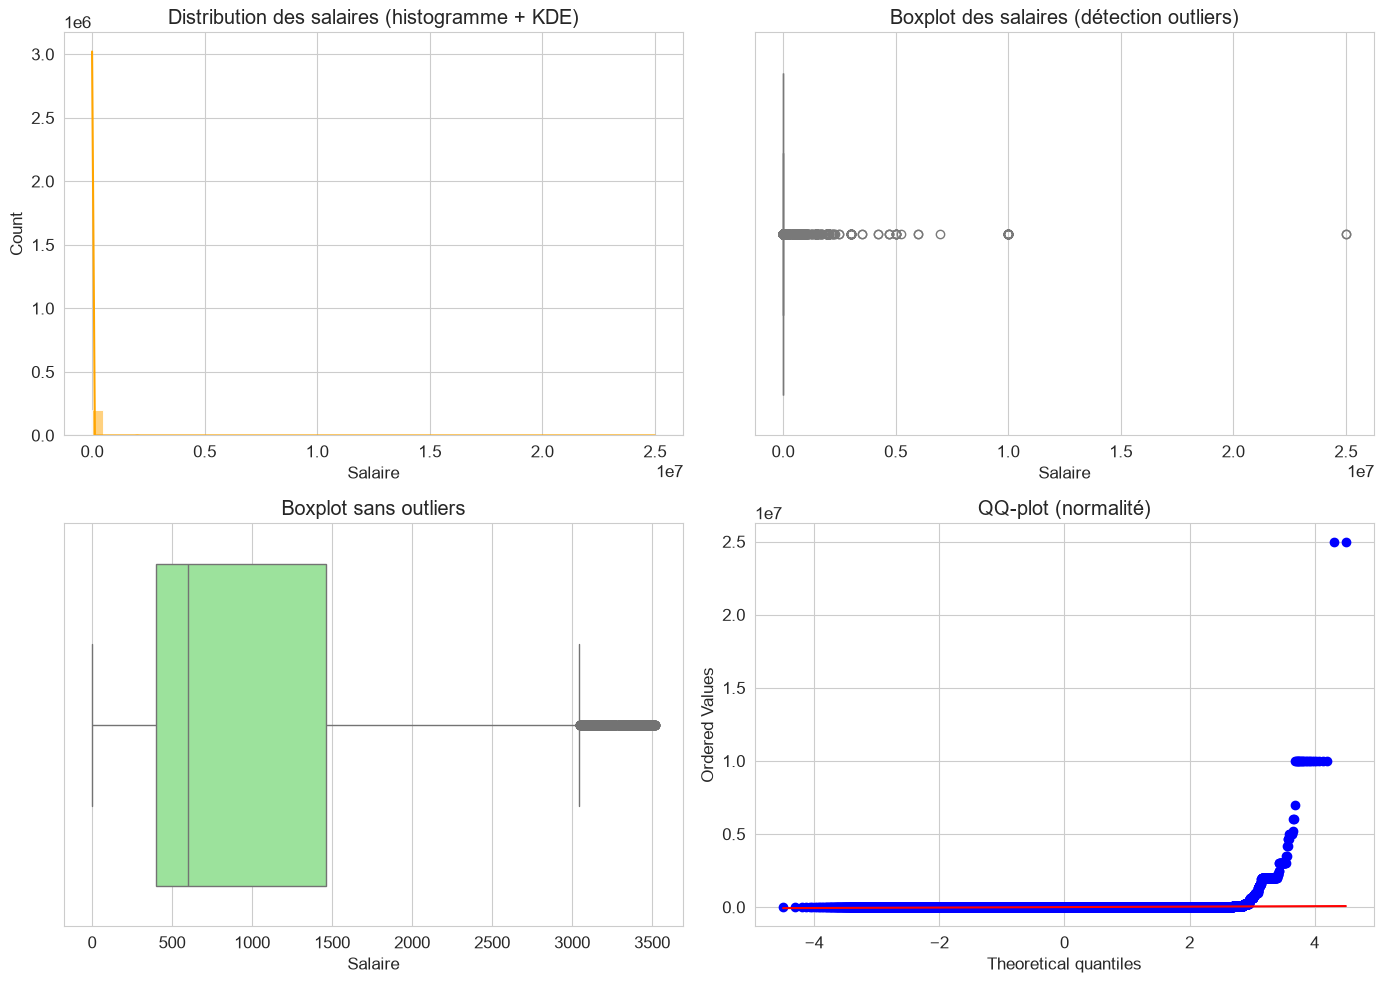

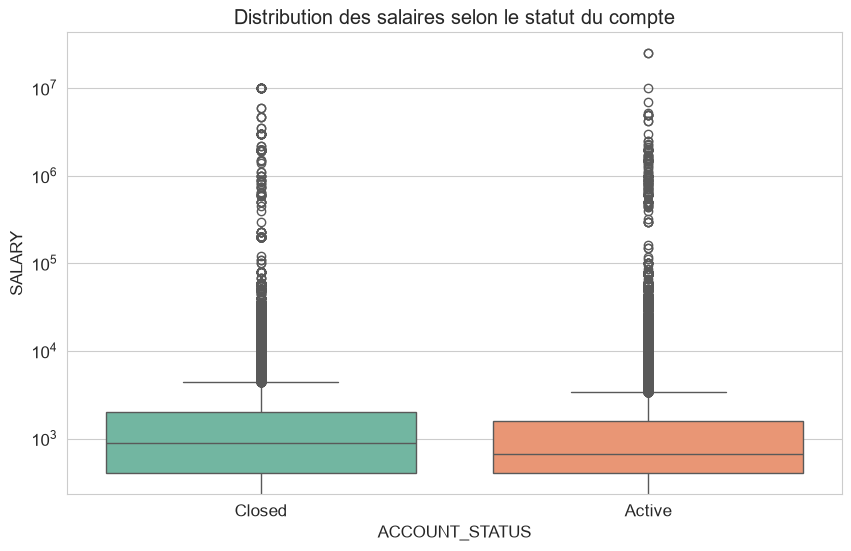


=== Test de Mann-Whitney (comparaison Active vs Closed) ===
p-value : 0.000000
Différence significative entre les deux groupes (p < 0.05)


In [17]:
# --- Analyse approfondie de SALARY ---
salary = df['SALARY'].dropna()

# 1. Statistiques de base
print("=== Statistiques descriptives de SALARY ===")
print(salary.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# 2. Quantiles spécifiques
quantiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print("\n=== Quantiles détaillés ===")
for q in quantiles:
    print(f"Quantile {q*100:.0f}% : {salary.quantile(q):.2f}")

# 3. Détection des outliers par la méthode IQR
Q1 = salary.quantile(0.25)
Q3 = salary.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = salary[(salary < lower_bound) | (salary > upper_bound)]
print(f"\n=== Outliers (IQR) ===")
print(f"Borne inférieure : {lower_bound:.2f}")
print(f"Borne supérieure : {upper_bound:.2f}")
print(f"Nombre d'outliers : {len(outliers)} ({len(outliers)/len(salary)*100:.2f}%)")

# 4. Visualisation : histogramme + KDE + boxplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogramme avec KDE
sns.histplot(salary, bins=50, kde=True, color='orange', ax=axes[0,0])
axes[0,0].set_title('Distribution des salaires (histogramme + KDE)')
axes[0,0].set_xlabel('Salaire')

# Boxplot vertical
sns.boxplot(x=salary, color='lightblue', ax=axes[0,1])
axes[0,1].set_title('Boxplot des salaires (détection outliers)')
axes[0,1].set_xlabel('Salaire')

# Boxplot après exclusion des outliers (pour mieux voir la distribution centrale)
salary_no_outliers = salary[(salary >= lower_bound) & (salary <= upper_bound)]
sns.boxplot(x=salary_no_outliers, color='lightgreen', ax=axes[1,0])
axes[1,0].set_title('Boxplot sans outliers')
axes[1,0].set_xlabel('Salaire')

# QQ-plot pour vérifier la normalité (optionnel)
from scipy import stats
stats.probplot(salary, dist="norm", plot=axes[1,1])
axes[1,1].set_title('QQ-plot (normalité)')

plt.tight_layout()
plt.show()

# 5. Comparaison du salaire selon le statut du compte (churn)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ACCOUNT_STATUS', y='SALARY', palette='Set2')
plt.title('Distribution des salaires selon le statut du compte')
plt.yscale('log')  # échelle log pour mieux visualiser si forte dispersion
plt.show()

# Test statistique (Mann-Whitney) pour comparer les distributions
from scipy.stats import mannwhitneyu
salary_active = df[df['ACCOUNT_STATUS'] == 'Active']['SALARY'].dropna()
salary_closed = df[df['ACCOUNT_STATUS'] == 'Closed']['SALARY'].dropna()
stat, p_value = mannwhitneyu(salary_active, salary_closed, alternative='two-sided')
print(f"\n=== Test de Mann-Whitney (comparaison Active vs Closed) ===")
print(f"p-value : {p_value:.6f}")
if p_value < 0.05:
    print("Différence significative entre les deux groupes (p < 0.05)")
else:
    print("Pas de différence significative")

### 6.4. Distribution du `ACCT_BALANCE`

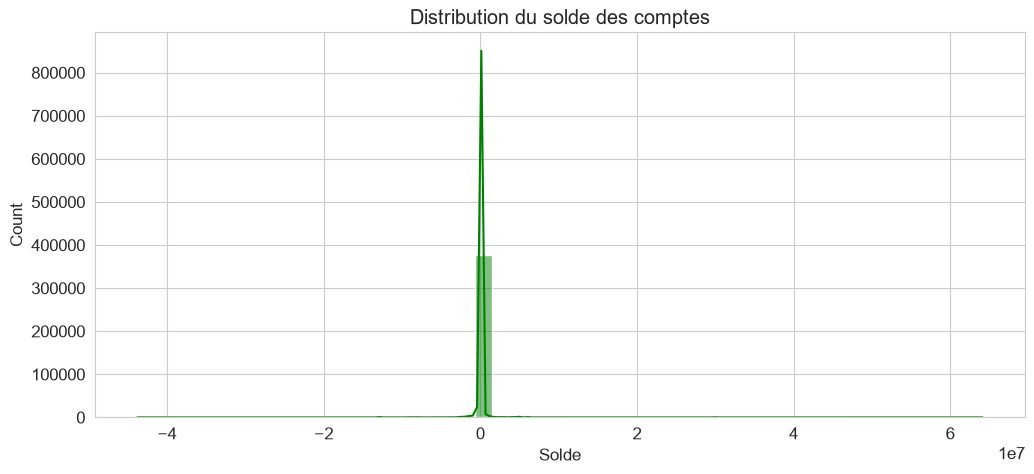

Solde moyen : 4409.02295
Solde médian : 2.09300


In [18]:
plt.figure(figsize=(12, 5))
sns.histplot(df['ACCT_BALANCE'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribution du solde des comptes')
plt.xlabel('Solde')
plt.show()

print(f"Solde moyen : {df['ACCT_BALANCE'].mean():.5f}")
print(f"Solde médian : {df['ACCT_BALANCE'].median():.5f}")

## 7. Analyse univariée des variables catégorielles clés

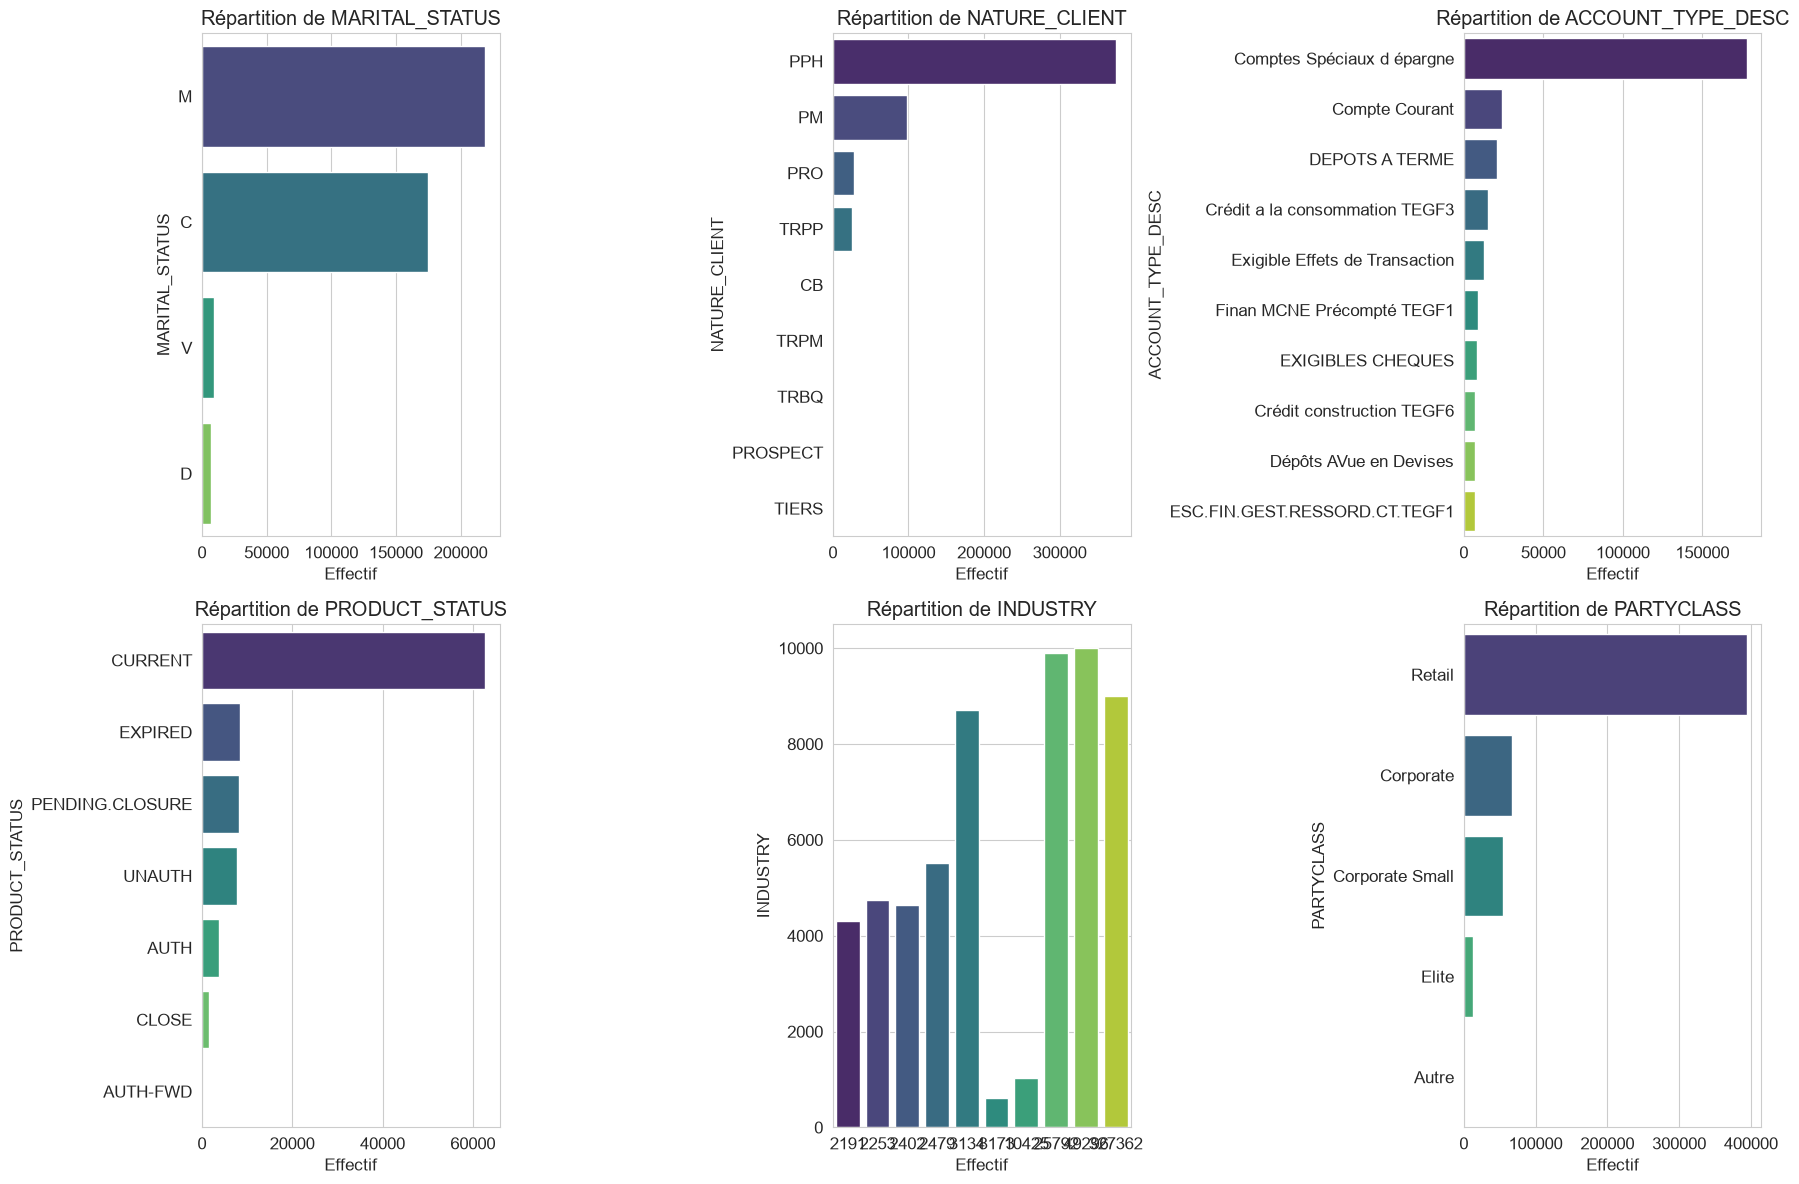

In [19]:
categorical_cols = ['MARITAL_STATUS', 'NATURE_CLIENT', 'ACCOUNT_TYPE_DESC', 'PRODUCT_STATUS', 'INDUSTRY', 'PARTYCLASS']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        counts = df[col].value_counts().head(10)
        sns.barplot(x=counts.values, y=counts.index, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Répartition de {col}')
        axes[i].set_xlabel('Effectif')

plt.tight_layout()
plt.show()

## 8. Relation entre le statut du compte (churn) et les variables


### 8.1. Churn par statut marital

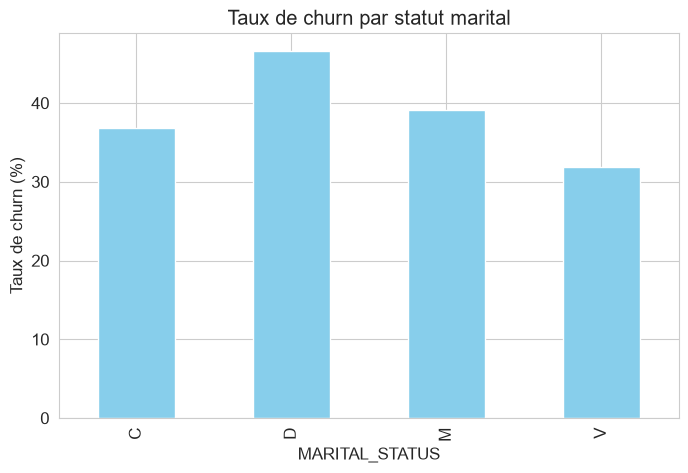

In [20]:
churn_by_marital = df.groupby('MARITAL_STATUS')['ACCOUNT_STATUS'].apply(lambda x: (x == 'Closed').mean() * 100)
plt.figure(figsize=(8, 5))
churn_by_marital.plot(kind='bar', color='skyblue')
plt.title('Taux de churn par statut marital')
plt.ylabel('Taux de churn (%)')
plt.show()

### 8.2. Churn par NATURE_CLIENT

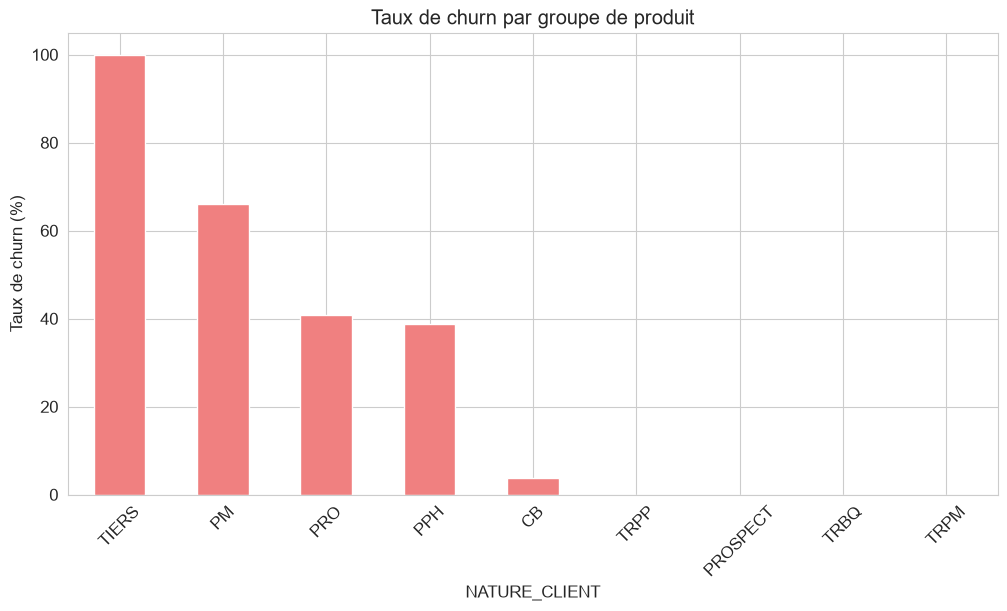

In [21]:
churn_by_product = df.groupby('NATURE_CLIENT')['ACCOUNT_STATUS'].apply(lambda x: (x == 'Closed').mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
churn_by_product.plot(kind='bar', color='lightcoral')
plt.title('Taux de churn par groupe de produit')
plt.ylabel('Taux de churn (%)')
plt.xticks(rotation=45)
plt.show()

### 8.3. Churn par INDUSTRY

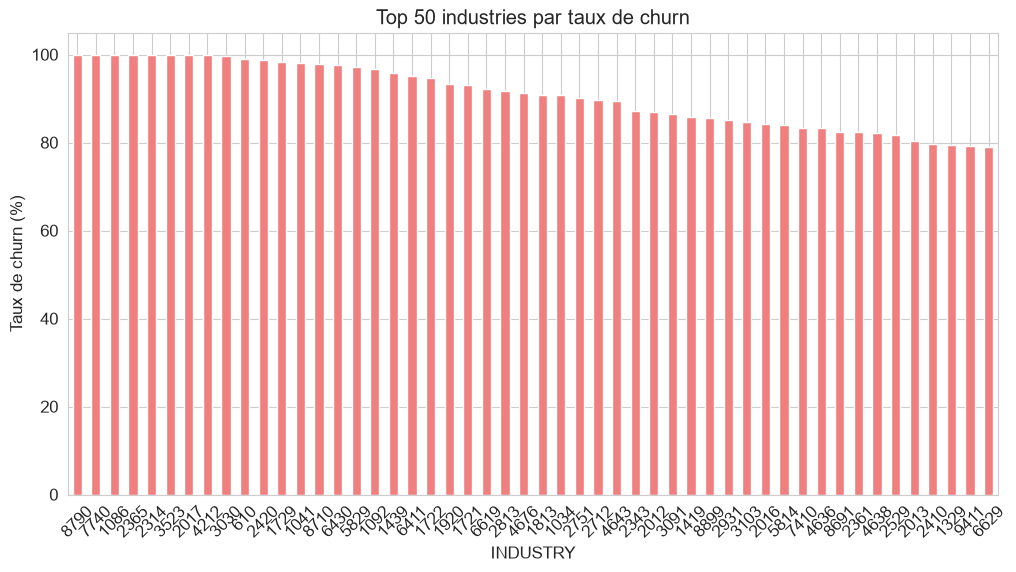

In [22]:
churn_by_product = (
    df.groupby(df['INDUSTRY'].astype(str))['ACCOUNT_STATUS']
      .apply(lambda x: (x == 'Closed').mean() * 100)
      .sort_values(ascending=False)
)

# Ne garder que les 5 premières industries
top5 = churn_by_product.head(50)

plt.figure(figsize=(12, 6))
top5.plot(kind='bar', color='lightcoral')
plt.title('Top 50 industries par taux de churn')
plt.ylabel('Taux de churn (%)')
plt.xticks(rotation=45)
plt.show()


### 8.4. Distribution de l'âge selon le statut

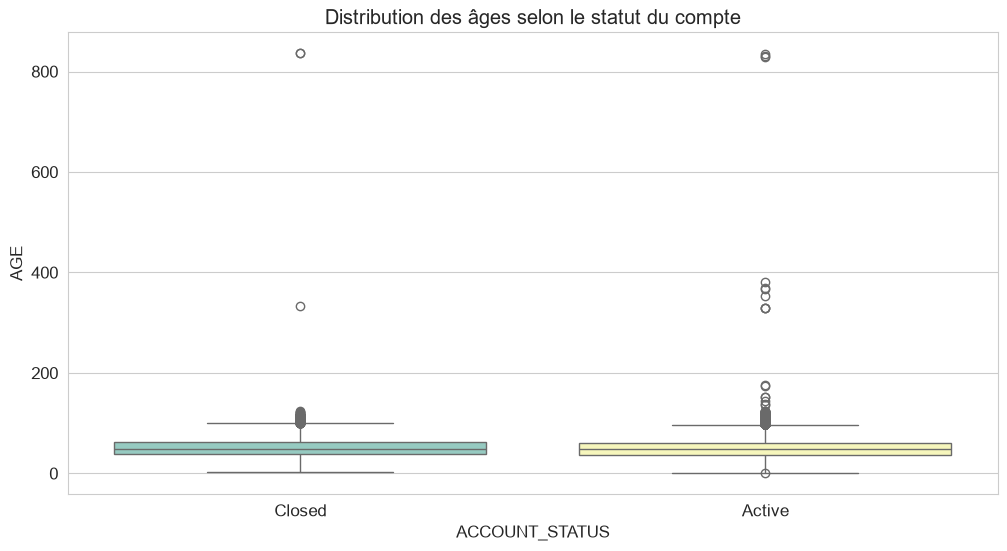

=== Statistiques descriptives de l'âge par statut de compte ===


,count,mean,std,min,25%,50%,75%,max
ACCOUNT_STATUS,,,,,,,,
Active,229862.00,48.62,17.43,0.00,37.00,48.00,61.00,835.00
Closed,156547.00,50.83,16.85,2.00,38.00,49.00,63.00,836.00


In [23]:
# Calcul de l'âge (approximatif)
def age_from_date_of_birth(dob):
    try:
        year = int(str(dob)[:4])
        return 2026 - year  # année de référence
    except:
        return np.nan

df['AGE'] = df['DATE_OF_BIRTH'].apply(age_from_date_of_birth)

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='ACCOUNT_STATUS', y='AGE', palette='Set3')
plt.title('Distribution des âges selon le statut du compte')
plt.show()

# Statistiques descriptives par statut et âge
stats_by_status = df.groupby('ACCOUNT_STATUS')['AGE'].describe()
print("=== Statistiques descriptives de l'âge par statut de compte ===")
stats_by_status




### 8.5. Solde moyen selon le statut

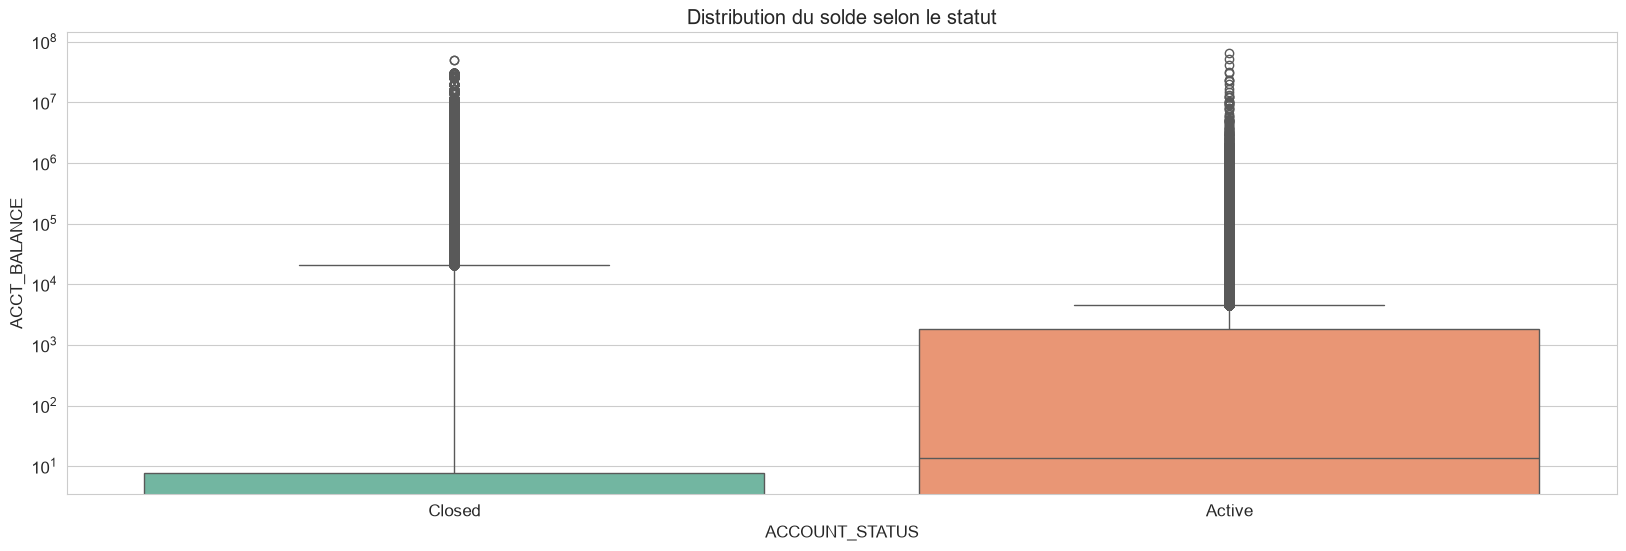

=== Statistiques descriptives du solde par statut de compte ===


,count,mean,std,min,25%,50%,75%,max
ACCOUNT_STATUS,,,,,,,,
Active,262502.00,-383.89,356107.66,-43823115.66,0.00,13.88,1821.44,64141930.15
Closed,121456.00,14767.90,1342785.38,-31601046.03,-13809.36,0.00,7.62,49147697.67


In [24]:
plt.figure(figsize=(20, 6))
sns.boxplot(data=df, x='ACCOUNT_STATUS', y='ACCT_BALANCE', palette='Set2')
plt.title('Distribution du solde selon le statut')
plt.yscale('log')
plt.show()

df["ACCT_BALANCE"]

# Statistiques descriptives par statut et ACCT_BALANCE
balance_by_status = df.groupby('ACCOUNT_STATUS')['ACCT_BALANCE'].describe()
print("=== Statistiques descriptives du solde par statut de compte ===")
balance_by_status



## 9. Matrice de corrélation entre variables numériques

## 10. Analyse temporelle

### 10.1. Évolution des ouvertures de comptes

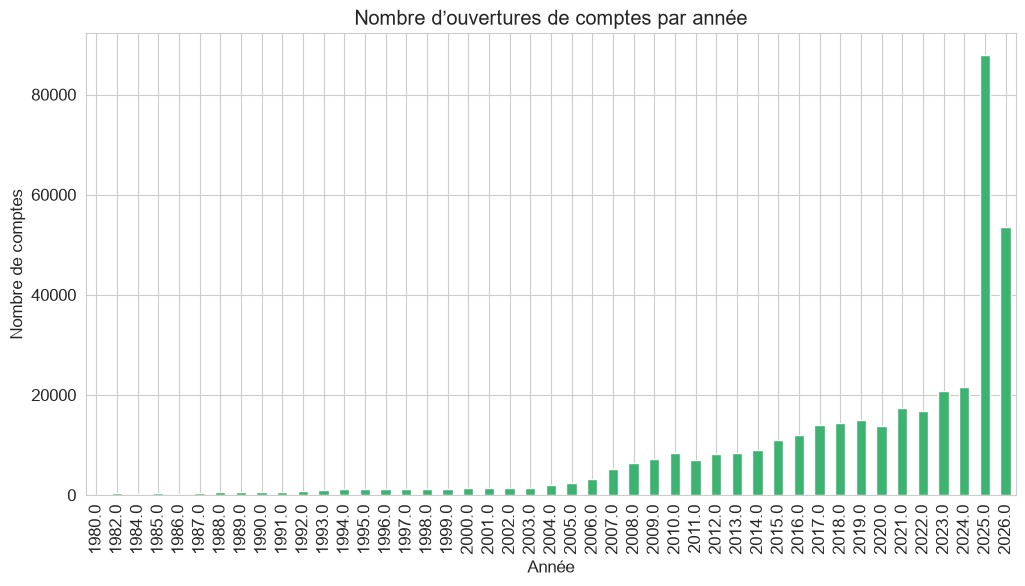

In [25]:
# Extraction de l'année d'ouverture
df['OPENING_YEAR'] = pd.to_numeric(df['ACCT_OPENING_DATE'].astype(str).str[:4], errors='coerce')

openings_by_year = df.groupby('OPENING_YEAR')['ACCOUNT_NO'].count()
plt.figure(figsize=(12, 6))
openings_by_year.plot(kind='bar', color='mediumseagreen')
plt.title('Nombre d’ouvertures de comptes par année')
plt.xlabel('Année')
plt.ylabel('Nombre de comptes')
plt.show()

### 10.2. Taux de churn par année d'ouverture

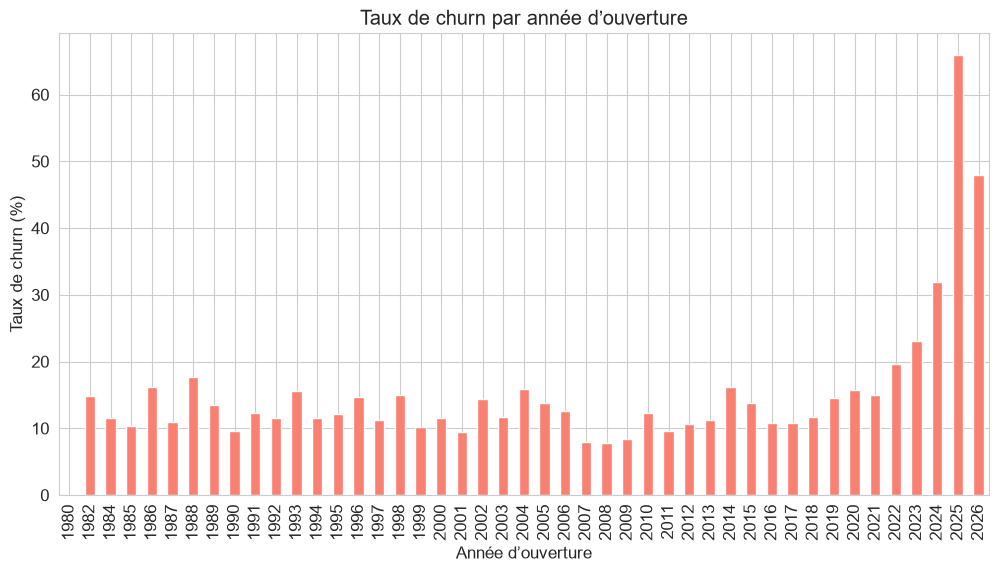

In [26]:

df['YEAR_OPENING'] = df['ACCT_OPENING_DATE'].dropna().astype(str).str[:4]

churn_by_open_year = df.groupby('YEAR_OPENING')['ACCOUNT_STATUS'].apply(lambda x: (x == 'Closed').mean() * 100)
plt.figure(figsize=(12, 6))
churn_by_open_year.plot(kind='bar', color='salmon')
plt.title('Taux de churn par année d’ouverture')
plt.xlabel('Année d’ouverture')
plt.ylabel('Taux de churn (%)')
plt.show()